<a href="https://colab.research.google.com/github/faizulhasson5-sudo/Protein-Expression-Neural-Network/blob/main/Protein_Expression_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
Generating Single-Cell Protein Expression Matrix...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)


Training Deep Neural Network...
Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.3472 - loss: 1.1701 - val_accuracy: 0.4167 - val_loss: 1.0641
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4398 - loss: 1.0233 - val_accuracy: 0.4583 - val_loss: 0.9712
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5139 - loss: 0.9163 - val_accuracy: 0.5833 - val_loss: 0.8788
Epoch 4/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6088 - loss: 0.8323 - val_accuracy: 0.7083 - val_loss: 0.7862
Epoch 5/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7153 - loss: 0.7423 - val_accuracy: 0.8125 - val_loss: 0.6914
Epoch 6/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8218 - loss: 0.6415 - val_accuracy: 0.8333 - val_loss: 0.5900
Epoch 7/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8519 - loss: 0.5480 - val_accuracy: 0.8542 - val_loss: 0.4943
Epoch 8/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8588 - loss: 0

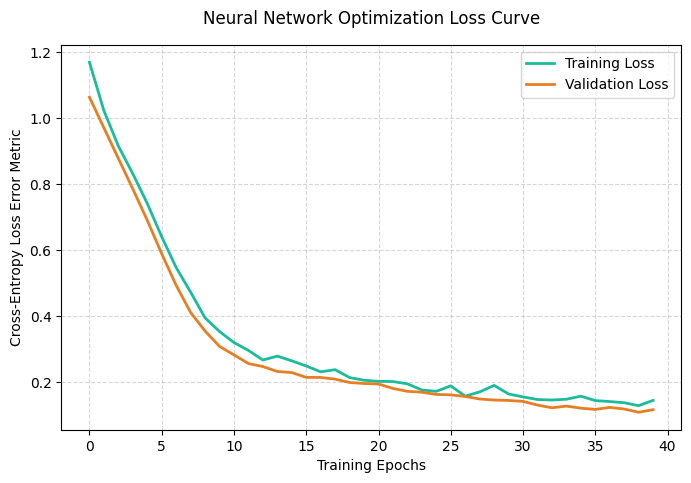

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

print(f"TensorFlow Version: {tf.__version__}")
print("Generating Single-Cell Protein Expression Matrix...")

# 1. Simulate Single-Cell Protein Expression Data
# Features: Abundance measurements for 4 distinct proteins (Prot_A, Prot_B, Prot_C, Prot_D)
# Target (Labels): 3 distinct tissue classes (0 = Lung, 1 = Liver, 2 = Heart)
np.random.seed(42)
n_cells = 600

# Create simulated biological profiles where different combinations mean different tissues
X_raw = np.random.uniform(0.1, 10.0, (n_cells, 4))
y_raw = np.zeros(n_cells, dtype=int)

for i in range(n_cells):
    if X_raw[i, 0] > 5.0 and X_raw[i, 1] < 4.0:
        y_raw[i] = 0  # Lung profile
    elif X_raw[i, 2] > 6.0:
        y_raw[i] = 1  # Liver profile
    else:
        y_raw[i] = 2  # Heart profile

# Split data into 80% training and 20% testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# 2. Scale Features (Crucial step for Deep Learning Optimization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 3. Architect the Multi-Layer Deep Neural Network
# Using a Sequential model with Dropout to prevent overfitting
model = Sequential(
    [
        Dense(32, activation="relu", input_shape=(4,)),  # Input layer + Hidden Layer 1
        Dropout(0.2),  # Regularization layer
        Dense(16, activation="relu"),  # Hidden Layer 2
        Dense(3, activation="softmax"),  # Output Layer (3 units for 3 tissue classes)
    ]
)

# Compile the deep learning model specifying cross-entropy loss for multi-class tasks
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

# 4. Train the Neural Network
print("\nTraining Deep Neural Network...")
history = model.fit(
    X_train, y_train, epochs=40, batch_size=16, validation_split=0.1, verbose=1
)

# 5. Evaluate Deep Learning Metrics
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- Deep Learning Final Evaluation ---")
print(f"Test Neural Accuracy: {accuracy * 100:.2f}%")

# 6. Plot Learning Curves (Loss Reduction Tracker)
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss", color="#1abc9c", lw=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="#e67e22", lw=2)
plt.title("Neural Network Optimization Loss Curve", fontsize=12, pad=15)
plt.xlabel("Training Epochs", fontsize=10)
plt.ylabel("Cross-Entropy Loss Error Metric", fontsize=10)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
